# Training Visualization Notebook
Generate graphs from training_log.csv

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Config ──────────────────────────────────────────────────────────
CSV_PATH = "../local/logs/training_log.csv"  # Change this to your CSV path
OUTPUT_DIR = "local/logs"                  # Where to save images

In [8]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} epochs")
df.head()

Loaded 11 epochs


,epoch,train_accuracy,train_loss,val_accuracy,val_loss
0,1,0.264723,10.760778,0.268519,12.214111
1,2,0.269235,10.458761,0.318827,11.724313
2,3,0.387118,9.728466,0.443056,11.120618
3,4,0.474397,9.051830,0.522222,10.572425
4,5,0.564331,8.235517,0.607716,9.925563


FileNotFoundError: [Errno 2] No such file or directory: 'local/logs/training_curves.png'

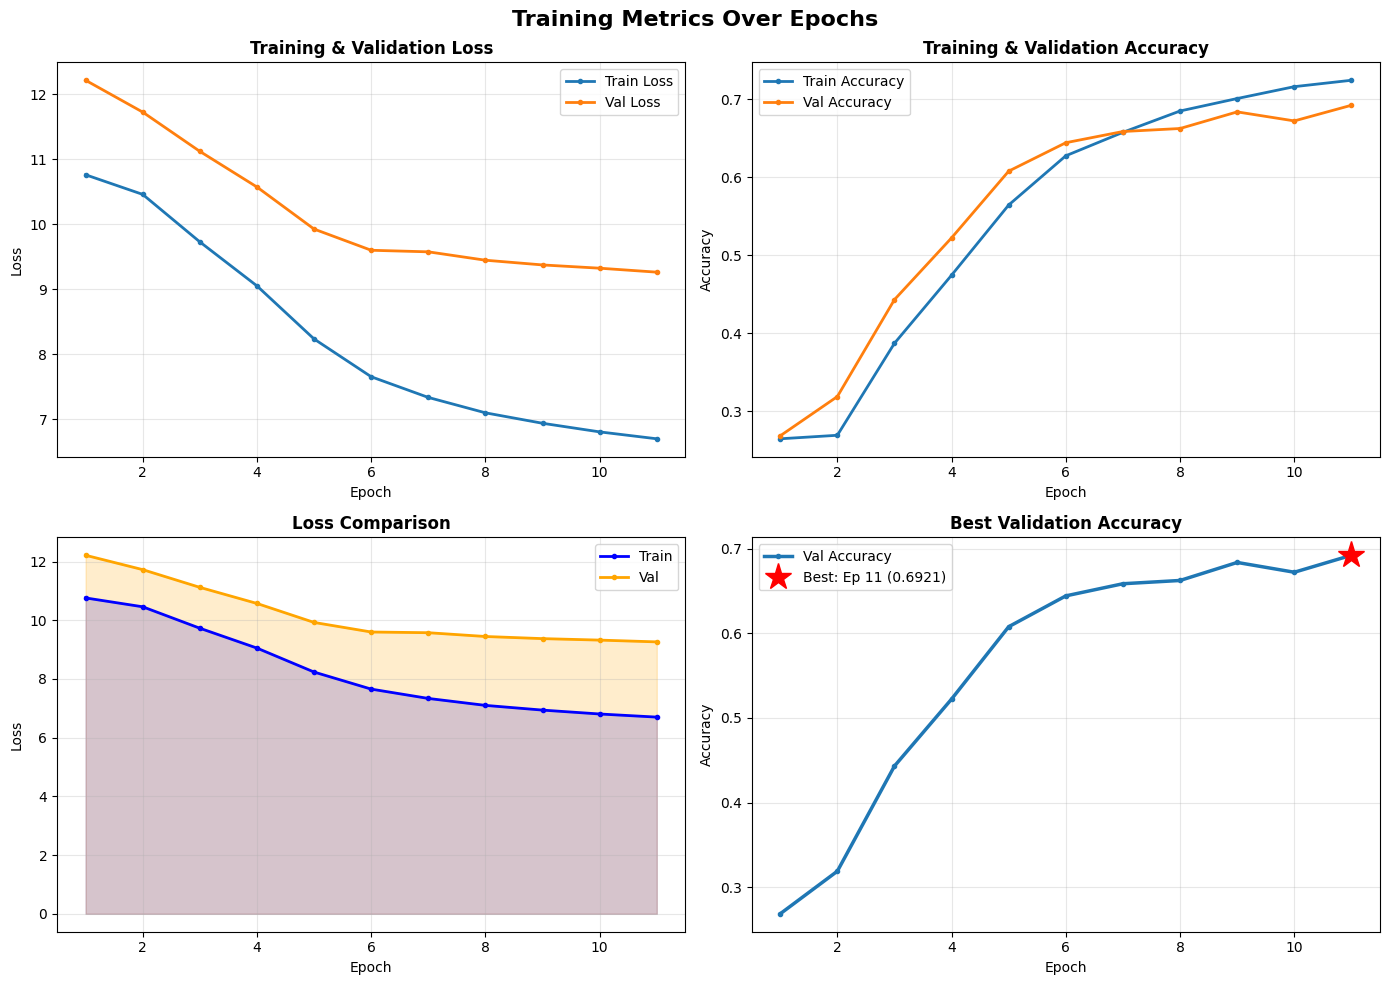

In [9]:
epochs = df["epoch"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training Metrics Over Epochs", fontsize=16, fontweight="bold")

# Loss
axes[0, 0].plot(epochs, df["train_loss"], label="Train Loss", linewidth=2, marker=".")
axes[0, 0].plot(epochs, df["val_loss"], label="Val Loss", linewidth=2, marker=".")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Training & Validation Loss", fontweight="bold")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, df["train_accuracy"], label="Train Accuracy", linewidth=2, marker=".")
axes[0, 1].plot(epochs, df["val_accuracy"], label="Val Accuracy", linewidth=2, marker=".")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Training & Validation Accuracy", fontweight="bold")
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Loss comparison with fill
axes[1, 0].plot(epochs, df["train_loss"], label="Train", linewidth=2, marker=".", color="blue")
axes[1, 0].fill_between(epochs, df["train_loss"], alpha=0.2, color="blue")
axes[1, 0].plot(epochs, df["val_loss"], label="Val", linewidth=2, marker=".", color="orange")
axes[1, 0].fill_between(epochs, df["val_loss"], alpha=0.2, color="orange")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Loss")
axes[1, 0].set_title("Loss Comparison", fontweight="bold")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# Best epoch marker
best_idx = df["val_accuracy"].idxmax()
best_ep = df.loc[best_idx, "epoch"]
best_acc = df.loc[best_idx, "val_accuracy"]
axes[1, 1].plot(epochs, df["val_accuracy"], label="Val Accuracy", linewidth=2.5, marker=".", markersize=6)
axes[1, 1].plot(best_ep, best_acc, "r*", markersize=20, label=f"Best: Ep {int(best_ep)} ({best_acc:.4f})")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Best Validation Accuracy", fontweight="bold")
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'local/logs/train_val_gap.png'

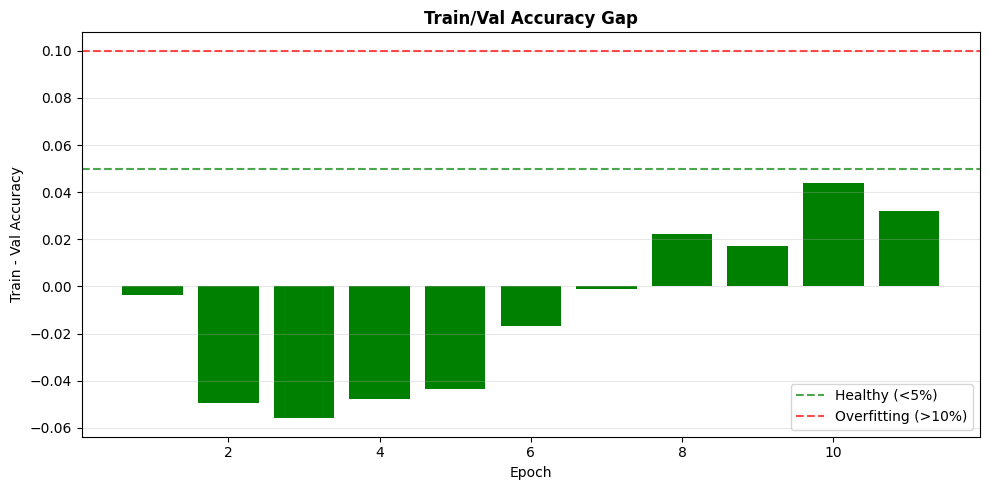

In [10]:
# Train/Val Gap (Overfitting Indicator)
gap = df["train_accuracy"] - df["val_accuracy"]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["green" if g < 0.05 else "orange" if g < 0.10 else "red" for g in gap]
ax.bar(epochs, gap, color=colors)
ax.axhline(y=0.05, color="green", linestyle="--", alpha=0.7, label="Healthy (<5%)")
ax.axhline(y=0.10, color="red", linestyle="--", alpha=0.7, label="Overfitting (>10%)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Train - Val Accuracy")
ax.set_title("Train/Val Accuracy Gap", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/train_val_gap.png", dpi=150, bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'local/logs/loss_convergence.png'

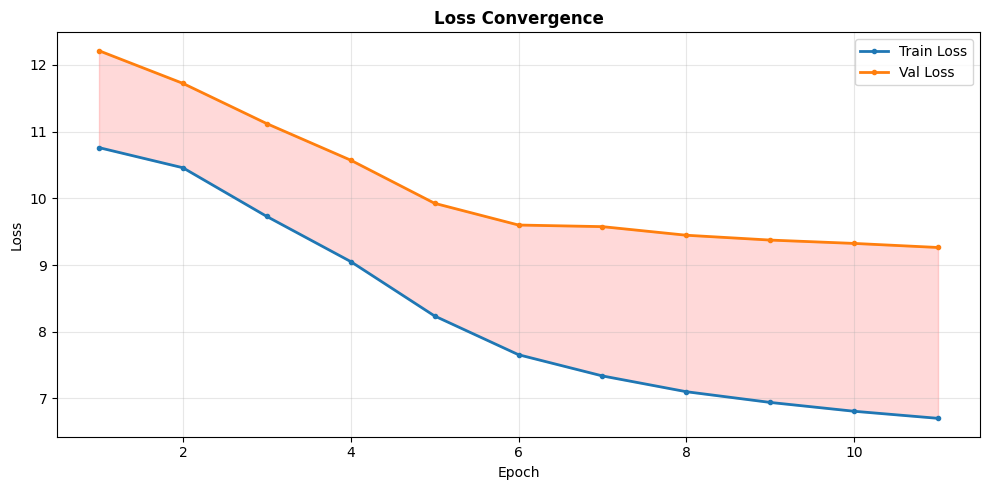

In [11]:
# Loss Convergence
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, df["train_loss"], label="Train Loss", linewidth=2, marker=".")
ax.plot(epochs, df["val_loss"], label="Val Loss", linewidth=2, marker=".")
ax.fill_between(epochs, df["train_loss"], df["val_loss"], alpha=0.15, color="red")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss Convergence", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print(f"Best val acc: {best_acc:.4f} at epoch {int(best_ep)}")
print(f"Final train/val gap: {gap.iloc[-1]:.4f}")

Best val acc: 0.6921 at epoch 11
Final train/val gap: 0.0320
